<a href="https://colab.research.google.com/github/Stonetenth2005/Machine-Learning/blob/main/19-ZScore-Outlier%20Removal/ZScore_Outlier_Removal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intuition - Based on the normal distribution of the data, use Z-Score to remove values from Mean - 3 Sigma to Mean + 3 Sigma

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


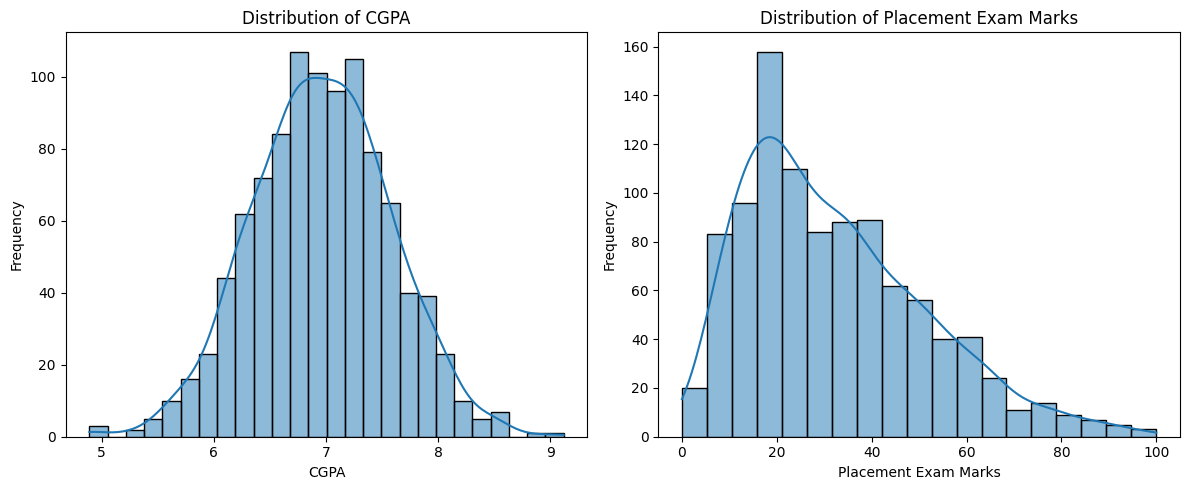

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')
plt.xlabel('Placement Exam Marks')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

It is clear that we should apply this method in CGPA column, because of column distribution

In [ ]:
print("Mean for CGPA :", df['cgpa'].mean())
print("Std for CGPA :", df['cgpa'].std())
print("Min for CGPA :", df['cgpa'].min())
print("Max for CGPA :", df['cgpa'].max())

Mean for CGPA : 6.96124
Std for CGPA : 0.6158978751323894
Min for CGPA : 4.89
Max for CGPA : 9.12


Finding the boundary values

In [ ]:
print("Highest allowed :", df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed :", df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed : 8.808933625397168
Lowest allowed : 5.113546374602832


Finding Outliers

In [ ]:
df[(df['cgpa']>8.808933625397168) | (df['cgpa']<6.2910663746028)]

,cgpa,placement_exam_marks,placed
13,5.68,26.0,0
23,6.05,11.0,0
25,6.28,58.0,1
32,5.91,11.0,1
33,6.23,27.0,0
...,...,...,...
992,6.26,12.0,0
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0


## Trimming

In [ ]:
new_df = df[(df['cgpa']<8.808933625397168) & (df['cgpa']>6.2910663746028)]

In [ ]:
new_df.shape

(854, 3)

## Capping

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [ ]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [ ]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961499,32.225000,0.489000
std,0.612688,19.130822,0.500129
min,5.113546,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,8.808934,100.000000,1.000000
